In [1620]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# %matplotlib widget
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft, ifft2, fftfreq, fftshift
import pandas as pd
import sympy as sy
from sympy import sin, exp, cos
from IPython.display import display, Markdown
from tqdm import tqdm

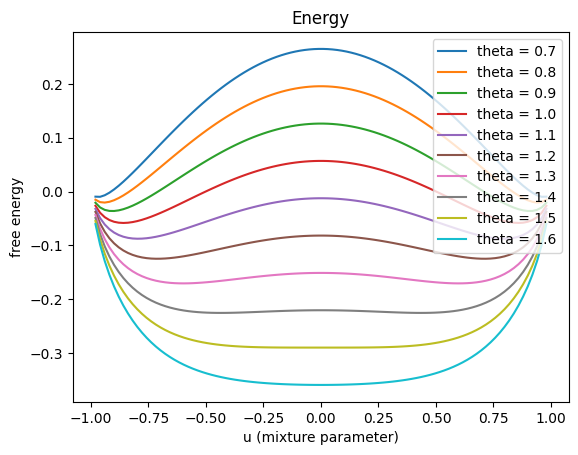

In [1621]:
#logartihmic potential
temperatur_thetas = np.arange(0.7,1.7,0.1)
u = np.linspace(-1,1,100)
critical_temperature = 1.5

def log_potential(u,theta):
    l1 = (critical_temperature/2)*(1-u**2)
    l2 = (theta/2)*((1-u)*np.log((1-u)/2)+(1+u)*np.log((1+u)/2))
    return l1 + l2

for theta in temperatur_thetas:
    y_vals = log_potential(u,theta)
    plt.plot(u,y_vals, label = f'theta = {np.round(theta,2)}')
    plt.legend()

plt.title("Energy")
plt.xlabel("u (mixture parameter)")
plt.ylabel("free energy")
plt.show()

In [1622]:

def biharmonic_solver(Lx,Ly,Nx,Ny, F, c, mean):
    F_hat = fft2(F)
    kx = fftfreq(Nx, d=Lx/Nx) * 2 * np.pi
    ky = fftfreq(Ny, d=Ly/Ny) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2+KY**2
    KfourierSpace = (K2**2 + c)
    KfourierSpace[0,0] = 1

    u_hat = F_hat/KfourierSpace
    u_hat[0,0] = mean

    U = ifft2(u_hat).real

    return U

In [1623]:
#parameters:
Nx1 = np.array([4,8,15,16,20,32])
Ny1 = 2*Nx1

k = np.arange(0,10)
Nx2 = 4+4*k
Ny2 =2*Nx2


In [1624]:
#manufacture solutions: 
def manufacture_solution_biharmonic(u_string, c):
    x, y = sy.symbols('x y')
    u_symbolic = eval(u_string)

    laplace = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    
    #beregner dobbel laplace på funksjonen (laplace^2)
    firstLaplace = laplace(u_symbolic)
    biharmonic = laplace(firstLaplace)
    f_symbolic = biharmonic + c*u_symbolic
    f_symbolic = sy.simplify(f_symbolic)

    u = sy.lambdify((x, y), u_symbolic, modules='numpy')
    f = sy.lambdify((x, y), f_symbolic, modules='numpy')

    return u,f


In [1625]:
u1_string = 'sin(8*(x-1))*cos(4*y)'
u1,f1 = manufacture_solution_biharmonic(u1_string, c = 1)

u2_string = 'exp(sin(x)**2+cos(2*y))'
u2,f2 = manufacture_solution_biharmonic(u2_string, c = 0)

KeyboardInterrupt: 

In [ ]:

def compute_errors(f,NX,NY,u,c):
    errors = []
    eocs = []
    for i in range(len(NX)):
        Lx = 2*np.pi
        Ly = 4*np.pi
        Nx = NX[i]
        Ny = NY[i]
        x = np.linspace(0,Lx,Nx, endpoint=False)
        y = np.linspace(0,Ly,Ny, endpoint=False)
        X,Y = np.meshgrid(x,y, indexing="ij")

        F = f(X,Y)
        U_ex = u(X,Y)
        U = biharmonic_solver(Lx,Ly,Nx,Ny,F,c, mean = 0)
        U += np.mean(U_ex)
        U_err = U - U_ex
        error = np.linalg.norm(U_err, np.inf)

        #append stuff
        errors.append(error)

        #convergences
        if len(errors) > 1:
            h_now = Lx / NX[i]
            h_prev = Lx / NX[i-1]
            eoc = np.log(errors[-1] / errors[-2]) / np.log(h_now / h_prev)
            eocs.append(eoc)
        else:
            eocs.append("Not yet...")

    return errors,eocs
        
errors1, eocs1 = compute_errors(f1,Nx1,Ny1,u1,c=1)
errors2, eocs2 = compute_errors(f2,Nx2,Ny2,u2,c=0)

In [ ]:
df1 = pd.DataFrame({
    'Nx': Nx1,
    'Ny': Ny1,
    'Error': errors1,
    'EOC': eocs1
})

df2 = pd.DataFrame({
    'Nx': Nx2,
    'Ny': Ny2,
    'Error': errors2,
    'EOC': eocs2
})


display(df1), display(df2)

,Nx,Ny,Error,EOC
0,4,8,1.818989e-12,Not yet...
1,8,16,3.784353e+02,-47.563903
2,15,30,9.827684e+00,5.807813
3,16,32,7.863653e-14,502.942163
4,20,40,6.159517e-13,-9.224252
5,32,64,1.001514e-12,-1.034246


,Nx,Ny,Error,EOC
0,4,8,9.573099e+01,Not yet...
1,8,16,8.456927e+01,0.178852
2,12,24,1.123358e+01,4.978638
3,16,32,3.294907e-01,12.267412
4,20,40,1.254177e-02,14.647448
5,24,48,7.612873e-04,15.367403
6,28,56,4.102912e-05,18.947233
7,32,64,2.124529e-06,22.172552
8,36,72,9.783264e-08,26.133196
9,40,80,4.265664e-09,29.732775


(None, None)

In [ ]:
#surface plot:

def surface_plot(Nx,Lx,Ly,f,u,c_in):
    Ny = 2*Nx
    x = np.linspace(0,Lx,Nx, endpoint=False)
    y = np.linspace(0,Ly,Ny, endpoint=False)
    X,Y = np.meshgrid(x,y, indexing="ij")

    F = f(X,Y)
    U_ex = u(X,Y)
    U = biharmonic_solver(Lx,Ly,Nx,Ny,F,c=c_in, mean = 0)
    U += np.mean(U_ex)
    U_err = U - U_ex

    fig = plt.figure(figsize=(25, 30))
    ax = fig.add_subplot(131, projection='3d')
    surf1 = ax.plot_surface(X, Y, U_ex, cmap='magma')
    fig.colorbar(surf1, shrink=0.2)
    ax.set_title("Exact Solution")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U_\mathrm{ex}$')

    ax = fig.add_subplot(132, projection='3d')
    surf2 = ax.plot_surface(X, Y,  U, cmap='Greens_r')
    fig.colorbar(surf2, shrink=0.2)
    ax.set_xlabel('X')
    ax.set_title(f'Numerical Solution, Nx: {Nx}')
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U(X, Y)$')

    ax = fig.add_subplot(133, projection='3d')
    surf3 = ax.plot_surface(X, Y,  U_err, cmap='coolwarm')
    fig.colorbar(surf3, shrink=0.2)
    ax.set_xlabel('X')
    ax.set_title("Error")
    ax.set_ylabel('Y')
    ax.set_zlabel(r'$U-U_{\mathrm{ex}}$')
    plt.tight_layout()
    plt.show()

   


surface_plot(15,2*np.pi,4*np.pi,f1,u1,1)
surface_plot(16,2*np.pi,4*np.pi,f1,u1,1)
surface_plot(32,2*np.pi,4*np.pi,f2,u2,0)


 40%|███▉      | 0.3953312499999123/1 [03:51<05:53, 584.39s/it]


KeyboardInterrupt: 

### Task 3

Vi begynner med $\theta$  - metoden; den er definert slik:

$
U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right), \quad \text{for } n = 0, 1, 2, \dots, N - 1
$

Herifra kan vi definere $k_1$ og $k_2$:

$k_1 = F(t_n, U^n)$  
$k_2 = F(t_{n+1}, U^{n+1}) = F(t_n + \tau, U^n + \tau(\theta k_2 + (1-\theta)k_1))$ 


*Nå kan vi skrive $\theta$  - metoden slik ved å benytte $k_1$ og $k_2$:*

$U^{n+1} = U^n + \tau \cdot (\theta k_2 + (1-\theta)k_1)$    

Fra dette kan vi utlede en generell butcher tabell ved å benytte at:

$$
k_j := f\left(t_k + c_j \tau,\ y_k + \tau \sum_{l=1}^{s} a_{jl} k_l\right), \quad j = 1, \dots, s,
$$  
  
$$
y_{k+1} := y_k + \tau \sum_{j=1}^{s} b_j k_j
$$

Butcher tabellen blir da i det generelle tilfellet slik:

$$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1 - \theta & \theta \\
\hline
  & 1 - \theta & \theta
\end{array}
$$

  

Fra dette observerer vi noen kjente Runge-Kutta metoder:

**Forward Euler** ( $\theta = 0$)

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 1 & 0 \\
\hline
  & 1 & 0
\end{array}
$

**Backward Euler** ($ \theta = 1 $)

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & 0 & 1 \\
\hline
  & 0 & 1
\end{array}
$

**Crank–Nicolson** ($ \theta = \frac{1}{2} $)

$
\begin{array}{c|cc}
0 & 0 & 0 \\
1 & \frac{1}{2} & \frac{1}{2} \\
\hline
  & \frac{1}{2} & \frac{1}{2}
\end{array}
$


**Konsistensorden for ulike $\theta$**   
*for å bestemme konsistensorden avhengig av theta benytter vi tabellen i forelesningsnotatene.*  
### Butcher-order conditions

| $p$ | Conditions |
|-----|------------|
| 1   | $\sum_{i=1}^{s} b_i = 1$ |
| 2   | $\sum_{i=1}^{s} b_i c_i = \frac{1}{2}$ |
| 3   | $\sum_{i=1}^{s} b_i c_i^2 = \frac{1}{3}$  <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} b_i a_{ij} c_j = \frac{1}{6}$ |
| 4   | $\sum_{i=1}^{s} b_i c_i^3 = \frac{1}{4}$ <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} b_i c_i a_{ij} c_j = \frac{1}{8}$ <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} b_i a_{ij} c_j^2 = \frac{1}{12}$ <br> $\sum_{i=1}^{s} \sum_{j=1}^{s} \sum_{k=1}^{s} b_i a_{ij} a_{jk} c_k = \frac{1}{24}$ |   

Det første vi kan legge merke til er at uavhengig av theta vil alle metodene ha minst konsistensorden 1.  
Dette er fordi summen av $\sum_{i=1}^{2} b_i = 1 - \theta + \theta = 1$


  








In [ ]:
theta = np.linspace(0,1,1000)
print("sjekk for noen theta verdier for konsistensorden:")
print("-------------------------------------")
for i in range(len(theta)):
    c1 = 0
    c2 = 1
    a11 = 0
    a12 = 0
    b1 = 1 - theta[i]
    b2 = theta[i]
    a21 = 1- theta[i]
    a22 = theta[i]
    #check for p = 2:
    sum = b1*c1+b2*c2
    if sum < 0.5005 and sum > 0.499:
        print("check for p = 2:")
        print("p = 2: ", np.round(theta[i],2))
        print("theta = 0.5 er dermed en theta verdi som gir konsistensorden 2!")

    #check for p = 3:

    sum1 = b1*c1**2+b2*c2**2
    if sum < 0.33334 and sum > 0.333:
        print("check for p = 3:")
        sum2 = b2*c2*a21 + b2*c2*a22
        print(sum2, " != ", 1/6)
        print("---------------------------------------")

sjekk for noen theta verdier for konsistensorden:
-------------------------------------
check for p = 3:
0.33333333333333337  !=  0.16666666666666666
---------------------------------------
check for p = 2:
p = 2:  0.5
theta = 0.5 er dermed en theta verdi som gir konsistensorden 2!


## kommentar til koden:

Kodesnutten itererer gjennom noen theta verdier og tester for konsistensorden 2 og 3.  
Ved konsistensorden 2 er det kun en verdi av theta som gir denne konsistensordenen. Nemlig $\theta = \frac{1}{2}$, altså Crank-Nicholson metoden! for konsistensorden 3 finnes at når theta 1/3 men dette stemmer ikke med den andre betingelsen, da kan vi si at ingen theta gir konsistensorden større enn 2.

###  Konklusjon:

- For $ \theta = 0 $: Forward Euler → orden 1
- For $ \theta = 1 $: Backward Euler → orden 1
- For $ \theta = \frac{1}{2} $: Crank–Nicolson → orden 2
- For andre verdier av $\theta $, metoden er 1. ordens nøyaktig

Dermed ser vi at kun for $\theta = 0.5 $ oppfylles alle betingelser for 2. ordens konsistens.


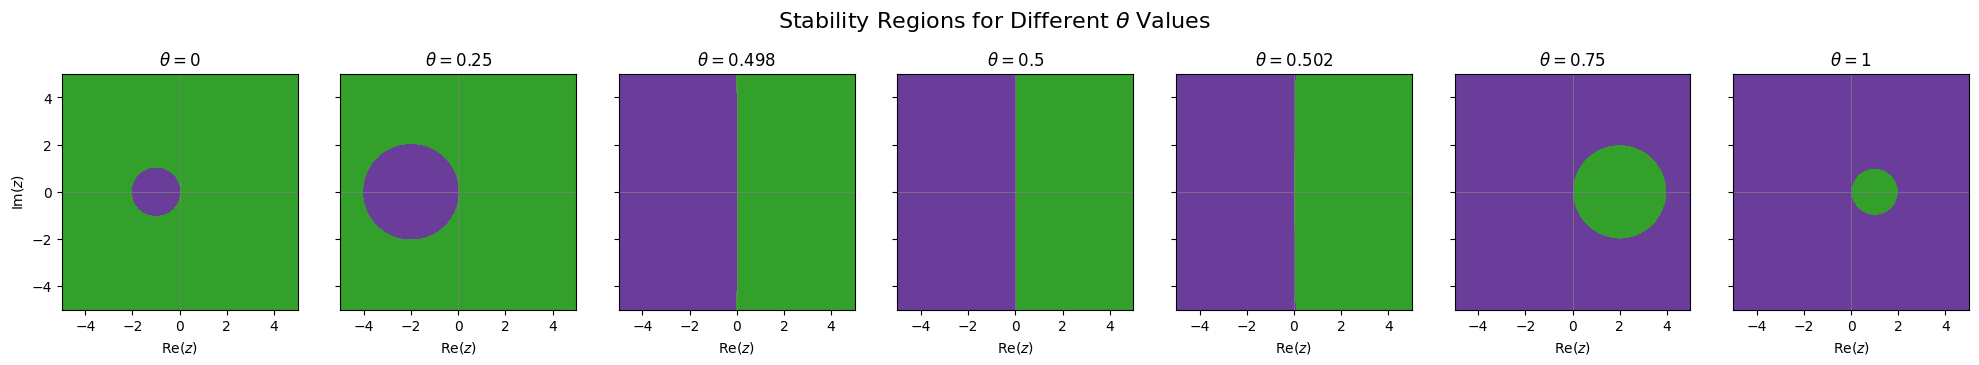

In [ ]:

a = np.linspace(-5, 5, 1000)
b = np.linspace(-5, 5, 1000)
A, B = np.meshgrid(a, b)
Z = A + B * 1j

# Stabilitetsfunksjonen
def Rz(Z, theta):
    R = 1 + Z / (1 - Z * theta)
    return np.abs(R)

fig, axes = plt.subplots(1, 7, figsize=(20, 5), sharex=True, sharey=True)

# Theta-verdier
theta_vals = [0, 0.25, 0.498, 0.5, 0.502,0.75,1]

# Plot hver region på sin egen aksis
for ax, theta in zip(axes, theta_vals):
    ax.contourf(A, B, Rz(Z, theta) <= 1, cmap='Paired', levels=1)
    ax.set_title(rf"$\theta = {theta}$")
    ax.set_xlabel("Re$(z)$")
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect("equal")

axes[0].set_ylabel("Im$(z)$")
fig.suptitle("Stability Regions for Different $\\theta$ Values", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=1.2)
plt.show()


# Theoretical Task 3

Stabilitetsfunksjonen utledes fra definisjonen av $\theta$ - metoden

$
U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right)$  

Og vi definerer:

$F(t_n, U^n) = \lambda \cdot U^n$  
$F(t_{n+1}, U^{n+1}) = \lambda \cdot U^{n+1} $

$U^{n+1} = U^n + \tau ((\theta \lambda \cdot U^{n+1})  + (1 - \theta) \lambda \cdot U^n ) $  

Vi gjør litt algebra her og definerer:

$Z = \lambda \tau$  

Deretter oppnår vi stabilitetsfunksjonen for metoden, som gir stabile områder der:
  
$r_{\theta}(Z) <= 1$

$r_{\theta}(Z) = \frac{U^{n+1}}{U^n} = 1 + \frac{Z}{1-Z \theta}$

Grensen for stabilitetsregionen er dermed gitt ved:  

$
\partial S_\theta = \left\{ z \in \mathbb{C} \;:\; |r_\theta(z)| = 1 \right\}
$

Fra dette kan vi prøve å forenkle uttrykket:
Vi starter med:   

$|r_\theta(z)| = 1 + \frac{Z}{1-Z \theta}|=  |\frac{1+Z(1-\theta)}{1-Z \theta}| = 1$

for komplekse brøker gjelder:

$|\frac{a}{b}| = \frac{|a|}{|b|}$

$|\frac{1+Z(1-\theta)}{1-Z \theta}| = 1 \iff 1+Z(1-\theta)| = |1-Z \theta|$  

Kvadrerer begge sidene:  

$|1+Z(1-\theta)|^2 = |1-Z \theta|^2$ 

Nå kan vi sette inn $x$ og $iy$ for z og oppnår:  

$|1+(x+iy)(1-\theta)|^2 = |1-(x+iy) \theta|^2$ 

samtidig benytter vi at for et komplekst tall at:

$|w|^2 = x^2 + y^2$  

Da kan vi skrive om likninga over til:  

$[1+x(1-\theta)]^2 + [y(1-\theta)]^2 = [1-x \theta]^2+[y \theta]^2$

nå kan vi utvide og forenkle uttrykk:

$(1 + 2x(1 - \theta) + x^2(1- \theta)^2) + y^2(1- \theta)^2 = (1 - 2x \theta + x^2 \theta^2) + y^2 \theta^2$

vi oppnår da:

$2x + (1 - 2\theta)(x^2+y^2) = 0$

Dette likner på likningen for en sirkel og vi innfører en ny variabel $\beta$ for å forenkle og fullfører kvadratet:  

$\beta = 1 - 2\theta$

$\frac{2x}{\beta} + x^2 + y^2 = 0$

Vi får sirkellikninga:  

$(x+\frac{1}{{\beta}})^2 + y^2 = \frac{1}{\beta^2}$

Vi kan gjøre noen generelle observasjoner her:  
- sentrum i sirkelen ligger i $-\frac{1}{\beta} = - \frac{1}{1 - 2\theta}$
- radiusen til sirkelen der metoden er stabil er $r = \frac{1}{|\beta|} = \frac{1}{|1 - 2\theta|}$
- Dette medfører at $\theta > 0$ 
- $\lim_{\theta \to \frac{1}{2}^{-}} \frac{1}{1 - 2\theta} = \infty$   Når 

### konklusjon:

for $\theta = \frac{1}{2}$ går stabilitetsregionens radius mot uendelig, dette betyr at hele venstre halvplan er A-stabilt  

altså $\theta > \frac{1}{2}$ = A-stabilt!

for  $\theta <> \frac{1}{2}$ er stabilitetsregionen en sirkel som ikke dekker hele halvplanet, dermed er den stabil i enkelte regioner, men ikke fullstendig A-stabil.
















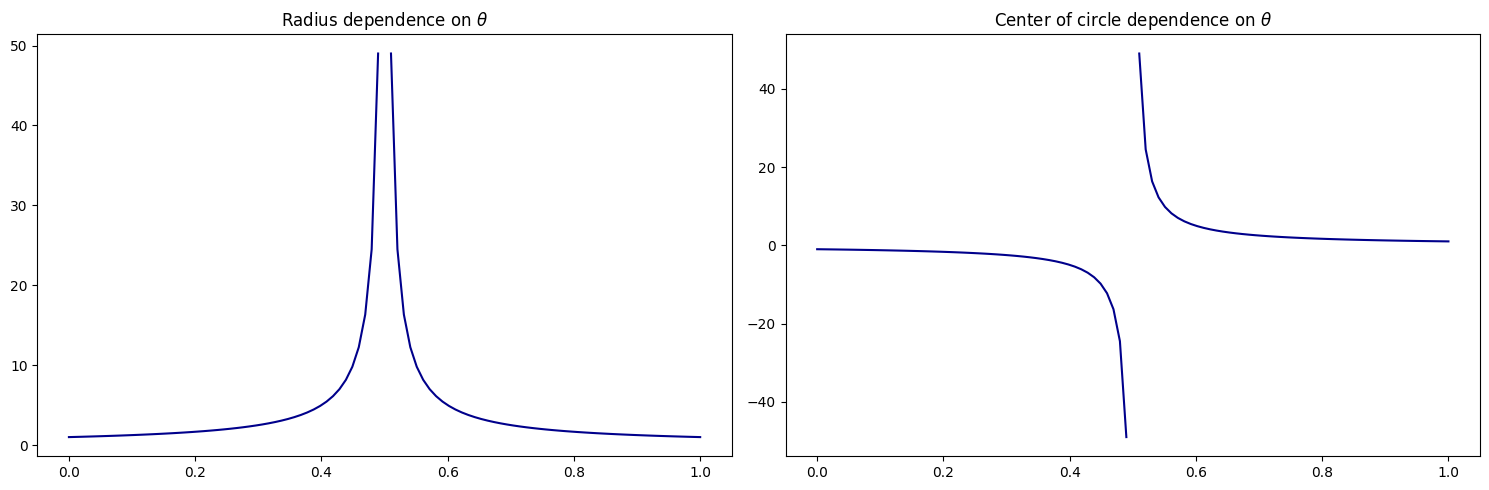

In [ ]:
theta1 = np.linspace(0,0.5,50)
theta2 = np.linspace(0.5,1,50)


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(theta1, 1 / (1 - 2 * theta1), color="darkblue")
ax[0].plot(theta2, -1 / (1 - 2 * theta2), color="darkblue")
ax[0].set_title(r"Radius dependence on $\theta$")

ax[1].plot(theta1, -1 / (1 - 2 * theta1), color="darkblue")
ax[1].plot(theta2, -1 / (1 - 2 * theta2), color="darkblue")
ax[1].set_title(r"Center of circle dependence on $\theta$")

plt.tight_layout()
plt.show()


## kommentar til plottet:

plottet til venstre viser for $\theta < \frac{1}{2}$ radiusen til stabilitetsregionen i det negative halplanet, og at denne går mot uendelig når $\theta = \frac{1}{2}$ det vil si hele det venstre halvplan. Dermed er Metoden A - stabil for denne $\theta$ verdien. For $\theta > \frac{1}{2}$ viser plottet en ikke-stabilitetsregion for det høyre halvplan, dette er dog ikke så relevant og alle $\theta > \frac{1}{2}$ er A-stabilt uansett! Ved samme argumentasjon viser plottet til høyre sentrum til sirkelene for samme $\theta$ verdier. Igjen er dette mest relevant for det negative halplan. Plottet viser også at når $\theta$ nærmer seg $\frac{1}{2}$ så går sentrum mot -$\infty$, altså at hele det venstre halvplanet er A-stabilt.

# Task 3 computanional:
*Mathematical Scheme*:

Vi skal benytte $\theta$ metoden:

$
U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right)$

$
\partial_t U = F(t, U), \qquad U(t_0) = U_0.
$


for å løse likningen:

$
\partial_t u + \kappa \Delta^2 u = g
$

Vi bruker disse til å bestemme at

$F(t, U) = g - \kappa \Delta^2 u$

I Fourierrommet får vi:

$\tilde{k} = 2 \pi (k_x,k_y)$
  
$F(t, U) = \hat{g} -\kappa |\tilde{k}|^4 \hat{u}$

deretter kan vi finne at:

$F(t_n, U^n) = \hat{g} -\kappa |\tilde{k}|^4 \hat{u}$  


$F(t_{n+1}, U^{n+1}) = \hat{g}^{n+1} -\kappa |\tilde{k}|^4 \hat{u}^{n+1}$  

vi setter inn i $\theta$ metoden og oppnår:

$\hat{u}^{n+1} = \hat{u}^{n} + \tau(\theta(\hat{g}^{n+1} -\kappa |\tilde{k}|^4 \hat{u}^{n+1}) + (1-\theta)(\hat{g} -\kappa |\tilde{k}|^4 \hat{u}))$

som kan skrives som:  

$\hat{u}^{n+1} = \frac{\hat{u}^{n}(1-\tau(1-\theta)\kappa|\tilde{k}|^4) + \tau(\theta \hat{g}^{n+1} + (1-\theta)\hat{g})}{1+\tau\theta\kappa\|\tilde{k}|^4}$

Som vi bruker i løseren vår.



In [ ]:
def transient_biharmonic_solver(*,kappa,X,Y,U0,t0,T,Nt,theta,g = None):
    x, y = X[0,:], Y[:,0]
    Nx, Ny = len(x), len(y)
    dx, dy = x[1] - x[0], y[1] - y[0]


    #beregner kx og ky i frekvensrommet
    kx = fftfreq(Nx, d=dx/(2*np.pi))
    ky = fftfreq(Ny, d=dy/(2*np.pi))
    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    #biharmonisk operator i frekvensrommet:
    K4 = (KX**2+KY**2)**2

    #time stepping
    t = t0
    dt = (T-t0)/Nt
    U_hat = fft2(U0)

    #returnerer startbetingelsene
    yield (U_hat, t)
    
    with tqdm(total=T) as pbar:
        while t < T-dt/2:
            if g is not None:
                G_hat = fft2(g(X,Y,t))
                G_hat_next = fft2(g(X,Y,t+dt))
            else:
                G_hat = 0
                G_hat_next = 0

            U_hat = (U_hat*(1-dt*(1-theta)*kappa*K4) + (dt*((theta*G_hat_next)+((1-theta)*G_hat))))/(1+dt*theta*kappa*K4)
            
            t = t + dt
            pbar.update(dt)
            yield U_hat, t


    

In [ ]:
#manufacture solutions
def manufacture_solution_transistent(u_string,kappa):

    x, y, t = sy.symbols('x y t')
    u_symbolic = eval(u_string)

    laplace = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    
    #beregner dobbel laplace på funksjonen (laplace^2)
    firstLaplace = laplace(u_symbolic)
    biharmonic = laplace(firstLaplace)
    g_symbolic = kappa*biharmonic + sy.diff(u_symbolic,t,1) 

    u = sy.lambdify((x, y, t), u_symbolic, modules='numpy')
    g = sy.lambdify((x, y, t), g_symbolic, modules='numpy')
    print(f'u = {u_symbolic}')
    print(f'u0 = {u_symbolic.subs(t, 0)}')
    print(f'g = {g_symbolic}')

    return u,g

In [ ]:
#løsningsforberedelser
Lx,Ly = np.pi,np.pi
Nx,Ny = 20,20
x = np.linspace(-Lx,Lx,Nx,endpoint=False)
y = np.linspace(-Ly,Ly,Ny,endpoint=False)
X,Y = np.meshgrid(x,y,sparse=True)

#parametere
kappa = 1
T,t0 = 1,0

#velger lambda lik 4, da blir g(x,y,t) lik 0
lamb = 4
Nt_list = [10,20,40,80,160,320,640]
g = None

#string representasjon av funksjonen
u_string_ex = 'sin(x)*cos(y)*exp(-lamb*kappa*t)'
u_ex,g_exact = manufacture_solution_transistent(u_string_ex,kappa)

u0 = u_ex
U0 = u0(X,Y,0)


u = exp(-4*t)*sin(x)*cos(y)
u0 = sin(x)*cos(y)
g = 0


In [ ]:
def compute_eoc_transient(*,
                          kappa, u_ex, U0, g,
                          X, Y, t0,theta, T, Nt_list):
    errs_Nt = [] 
    for Nt in Nt_list:
        U_list = transient_biharmonic_solver(kappa=kappa,X=X,Y=Y,U0=U0,
                                        t0=t0,T=T,Nt=Nt,theta=theta,g = g)
        errs_t = []
        for U, t in U_list:
            U = ifft2(U).real
            U_ex = u_ex(X,Y,t)
            U_err = U - U_ex
            errs_t.append(np.linalg.norm(U_err, np.inf))
        errs_Nt.append(np.array(np.linalg.norm(errs_t, np.inf)))
        
    Nt_list = np.array(Nt_list)
    errs_Nt = np.array(errs_Nt)
    eocs = np.log(errs_Nt[1:]/errs_Nt[:-1])/np.log(Nt_list[:-1]/Nt_list[1:])
    eocs = np.insert(eocs, 0, np.inf)
    return errs_Nt, eocs


u0 = u_ex
U0 = u0(X,Y,0)

errs1, eocs1 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=1, T=T, Nt_list=Nt_list)
errs2, eocs2 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=0.5, T=T, Nt_list=Nt_list)

errs3, eocs3 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=0, T=T, Nt_list=Nt_list)    



display(Markdown(r"### 📊 Konvergenstabell for $\theta = 1$"))
table = pd.DataFrame({'Nt': Nt_list, 'error': errs1, 'EOC': eocs1})
display(table)
display(Markdown(r"### 📊 Konvergenstabell for $\theta = 0.5$"))
table = pd.DataFrame({'Nt': Nt_list, 'error': errs2, 'EOC': eocs2})
display(table)
display(Markdown(r"### 📊 Konvergenstabell for $\theta = 0$"))
table = pd.DataFrame({'Nt': Nt_list, 'error': errs3, 'EOC': eocs3})
display(table)

100%|█████████▉| 0.9999999999999999/1 [00:00<?, ?it/s]
100%|██████████| 1.0000000000000002/1 [00:00<00:00, 1951.75it/s]
100%|██████████| 1.0000000000000004/1 [00:00<?, ?it/s]
100%|█████████▉| 0.9999999999999984/1 [00:00<00:00, 48.41it/s]
100%|█████████▉| 0.9999999999999974/1 [00:00<00:00, 68.33it/s]
100%|██████████| 1.0000000000000058/1 [00:00<00:00, 55.65it/s]
100%|██████████| 1.00000000000001/1 [00:00<00:00, 26.67it/s]
100%|█████████▉| 0.9999999999999999/1 [00:00<00:00, 501.17it/s]
100%|██████████| 1.0000000000000002/1 [00:00<00:00, 999.12it/s]
100%|██████████| 1.0000000000000004/1 [00:00<00:00, 333.41it/s]
100%|█████████▉| 0.9999999999999984/1 [00:00<00:00, 1348.22it/s]
100%|█████████▉| 0.9999999999999974/1 [00:00<00:00, 68.06it/s]
100%|██████████| 1.0000000000000058/1 [00:00<00:00, 53.67it/s]
100%|██████████| 1.00000000000001/1 [00:00<00:00, 28.78it/s]
100%|█████████▉| 0.9999999999999999/1 [00:00<00:00, 999.60it/s]
100%|██████████| 1.0000000000000002/1 [00:00<00:00, 497.78it/s]
100

### 📊 Konvergenstabell for $\theta = 1$

,Nt,error,EOC
0,10,0.798529,inf
1,20,0.429312,0.895320
2,40,0.223050,0.944656
3,80,0.113774,0.971194
4,160,0.057470,0.985292
5,320,0.028883,0.992567
6,640,0.014479,0.996263


### 📊 Konvergenstabell for $\theta = 0.5$

,Nt,error,EOC
0,10,0.061848,inf
1,20,0.015552,1.991623
2,40,0.003875,2.004710
3,80,0.000968,2.001173
4,160,0.000242,2.000293
5,320,0.000060,2.000073
6,640,0.000015,2.000018


### 📊 Konvergenstabell for $\theta = 0$

,Nt,error,EOC
0,10,1.752704e+19,inf
1,20,9.810651e+48,-98.820681
2,40,8.019770e+102,-179.093329
3,80,5.868343e+198,-318.454490
4,160,NaN,NaN
5,320,NaN,NaN
6,640,NaN,NaN


# Diskusjon av resultater

Vi gjentar resultatene fra teoridelen: 
- sentrum i sirkelen ligger i $-\frac{1}{\beta} = - \frac{1}{1 - 2\theta}$
- radiusen til sirkelen der metoden er stabil er $r = \frac{1}{|\beta|} = \frac{1}{|1 - 2\theta|}$ (komplementet når $\theta > \frac{1}{2}$)
- $Z = \lambda \tau = 4 \tau$
- $R_{\theta}(z) = 1 + \frac{z}{1-z\theta} = 1 + \frac{4 \tau}{1-4 \tau\theta}$

Først og fremst fant vi ut fra teoridelen at:

| $ \theta$  | Orden  p  |
|:------------:|:-------------:|
| 0            | 1             |
| 0.5          | 2             |
| 1            | 1             |  
----------------------


| $\theta$ | Stabilitetsradius $R$  | Sentrum til stabilitetsregionen |
|:------------:|:--------------:|:-------:|
| 0            |        1        |    -1     |
| 0.5          |        A-stabil        |    A-stabil      |
| 1            |         A-stabil       |     A-stabil    |


For $\theta$ = 0 observerer vi at $R_{\theta}(z) > 1$, som gjør at alle Z er utenfor stabilitetsregionen. Derfor blir metoden helt crazy for denne thetaverdien (og $\lambda = 4$). For $\theta$ = 0.5 og $\theta$ = 1. vil alle Z være innenfor stabilitetsregionen, og dermed følger konvergensraten den teoretiske bra!

### CFL -betingelse for $\theta = 0$:

Vi begynner med den generelle $\theta$ metoden   

$U^{n+1} = U^n + \tau \left( \theta F(t_{n+1}, U^{n+1}) + (1 - \theta) F(t_n, U^n) \right)$

Med $\theta = 0$ reduseres dette til Forward Euler:

$U^{n+1} = U^n + \tau F(t_n, U^n)$

I vårt tilfelle er:

$F(t, U) = g - \kappa \Delta^2 u$

$U^{n+1} = U^n + \tau (g - \kappa \Delta^2 u) $

DFT gir:

$\hat{u}^{n+1} = \hat{u}^{n}(1 -\tau \kappa |\tilde{K}|^4 )$

Stabilitetsbetingelsen er gitt ved: 
   
$
\left|1 - \tau \kappa |\tilde{K}|^4\right| \leq 1
$

$
-1 \le 1 - \tau \kappa |\tilde{K}|^4 \le 1
$  

$
0 \le \tau \kappa |\tilde{K}|^4 \le 2
$

Vi ser på den høyre delen, siden det er den som gir oss en positiv øvre grense på $\tau $:

$
\boxed{
\tau \le \frac{2}{\kappa |\tilde{K}|^4}
}
$

Vi vet også at den største frekvensen K kan ha er:

$|\tilde{K}|_{max} = \frac{\pi N}{L}$

$|\tilde{K}|_{max}^4 = \frac{\pi^4 N^4}{L^4}$

Vi setter inn og får:

$\tau \le  \frac{2 L^4}{\kappa \pi^4 N^4}$


$
\tau = \frac{T}{N_t} \leq \frac{2 L^4}{\kappa \pi^4 N^4}
\quad \Rightarrow \quad 
N_t \geq \frac{\kappa T |\tilde{K}|_{\text{max}}^4}{2}
$


Vi får dermed:
$
N_t \geq  \frac{\kappa T \pi^4 N^4}{2 L^4}
$

Så det minimale antallet tidsskritt blir:
$
N_t^{\min} = \frac{\kappa T \pi^4 N^4}{2 L^4}
$


### Konklusjon:

Forward Euler ($ \theta = 0 $) gir en ekstremt ineffektiv metode for den transiente biharmoniske ligningen.  
Stabilitetsbetingelsen viser at:

- Tidssteget må tilfredsstille $ \tau \le \frac{2 L^4}{\kappa \pi^4 N^4} $
- Det betyr at hvis vi dobler antall gridpunkter $N$, må vi bruke 16 ganger flere tidssteg for å opprettholde stabilitet.
- Allerede ved $ N = 10 $ gir dette:
  $
  \tau \le \frac{2}{10^4} = 0.0002
  $
  som er ekstremt små tidssteg for en lav verdi av $ N $

Implikasjon:  
**Eksplisitte metoder er upraktiske for slike ligninger**, og man bør bruke en A-stabil metode (f.eks. $ \theta \ge 0.5 $).



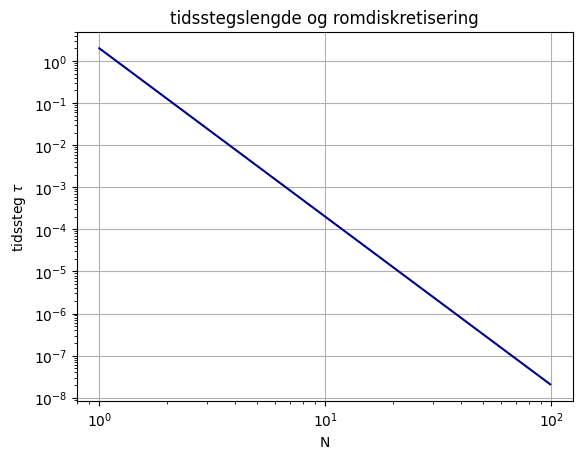

In [ ]:
N = np.arange(1,100)
plt.loglog(N,2/N**4, color ="darkblue")
plt.grid()
plt.title("tidsstegslengde og romdiskretisering")
plt.xlabel("N")
plt.ylabel(r'tidssteg $\tau$')
plt.show()

In [ ]:
N_cfl = 80000

Nt_list = [int(0.5*N_cfl), N_cfl, 2*N_cfl,4*N_cfl]

errs3, eocs3 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=0, T=T, Nt_list=Nt_list) 

display(Markdown(r"### 📊 Konvergenstabell for $\theta = 0$"))
table = pd.DataFrame({'Nt': Nt_list, 'error': errs3, 'EOC': eocs3})
display(table)

100%|██████████| 1.000000000001004/1 [00:03<00:00,  3.83s/it]   
100%|█████████▉| 0.9999999999993368/1 [00:08<00:00,  8.04s/it]  
 40%|███▉      | 0.3952499999999125/1 [00:05<00:09, 16.41s/it]  

KeyboardInterrupt: 

In [ ]:
#string representasjon av funksjonen
u_string_ex = '(exp(1+sin(x)*sin(x)) + exp(1+cos(y)*cos(y)))*exp(-4*kappa*t)'
u_ex,g_exact = manufacture_solution_transistent(u_string_ex,kappa)

u0 = u_ex
U0 = u0(X,Y,0)
g = g_exact


errs1, eocs1 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=1, T=T, Nt_list=Nt_list)
errs2, eocs2 = compute_eoc_transient(kappa=kappa, 
                                   u_ex=u0, U0=U0, g=g,
                                   X=X, Y=Y, t0=t0,theta=0.5, T=T, Nt_list=Nt_list)

display(Markdown(r"### 📊 Konvergenstabell for $\theta = 1$"))
table1 = pd.DataFrame({'Nt': Nt_list, 'error': errs1, 'EOC': eocs1})
display(table1)
display(Markdown(r"### 📊 Konvergenstabell for $\theta = 0.5$"))
table2 = pd.DataFrame({'Nt': Nt_list, 'error': errs2, 'EOC': eocs2})
display(table2)

u = (exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))*exp(-4*t)
u0 = exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1)
g = -4*(exp(sin(x)**2 + 1) + exp(cos(y)**2 + 1))*exp(-4*t) + 4*(2*(2*sin(x)**2*cos(x)**2 - sin(x)**2 + cos(x)**2)*sin(x)**2*cos(x)**2 - (2*sin(x)**2*cos(x)**2 - sin(x)**2 + cos(x)**2)*sin(x)**2 + (2*sin(x)**2*cos(x)**2 - sin(x)**2 + cos(x)**2)*cos(x)**2 - 8*(sin(x)**2 - cos(x)**2 + 1)*sin(x)**2*cos(x)**2 + 2*sin(x)**4 - 12*sin(x)**2*cos(x)**2 + 2*sin(x)**2 + 2*cos(x)**4 - 2*cos(x)**2)*exp(-4*t)*exp(sin(x)**2 + 1) + 4*(2*(2*sin(y)**2*cos(y)**2 + sin(y)**2 - cos(y)**2)*sin(y)**2*cos(y)**2 + (2*sin(y)**2*cos(y)**2 + sin(y)**2 - cos(y)**2)*sin(y)**2 - (2*sin(y)**2*cos(y)**2 + sin(y)**2 - cos(y)**2)*cos(y)**2 - 8*(-sin(y)**2 + cos(y)**2 + 1)*sin(y)**2*cos(y)**2 + 2*sin(y)**4 - 12*sin(y)**2*cos(y)**2 - 2*sin(y)**2 + 2*cos(y)**4 + 2*cos(y)**2)*exp(-4*t)*exp(cos(y)**2 + 1)


 30%|███       | 0.3017249999999709/1 [00:05<00:11, 16.84s/it]


KeyboardInterrupt: 

Vi kan se at også i denne konvergensstudien ser metodene ut til å ha konvergensorden lik 1 og 2, som da g = 0.


# task 4: IMEX- solver
**matematisk begrunnelse:**

vi skal innføre en implisitt - eksplisitt metode, som vil si at vi splitter opp ledd og beregner både implisitt og eksplisitt. Det antas at $\theta$ metoden er kjent og vi starter med å beskrive $F(t_n,U^n)$ og $F(t_n + \tau, U^{n+1})$  

Vi starter med:  

$
\partial_t u - \nabla \cdot \left( M \nabla(f(u)) - \kappa \Delta u \right) = g
$

$
\partial_t u = g + M\Delta(f(u)) + \kappa\Delta^2u
$

$\Delta f(u)$ er definert som:
  
$\Delta f(u) = \Delta(u^3-u) = \alpha\Delta u + \Delta u^3 - (1+\alpha)\Delta u $

Vi får da:  


$
\partial_t u = g + M(\alpha\Delta u + \Delta u^3 - (1+\alpha)\Delta u) + \kappa\Delta^2u
$


*Nå kan vi dele inn i eksplisitt og implisitt del:*

Eksplisitt del:  

$F(t_n,U^n) = M(\Delta (u^n)^3 - (1+\alpha)\Delta u^n)$

Implisitt del :

$F(t_n + \tau, U^{n+1}) = g^{n+1} + M \alpha \Delta u^{n+1} - \kappa \Delta^2 u^{n+1}$  


Vi kan nå kombinere de til ett uttrykk:  

$u^{n+1} = u^n + \tau M(\Delta (u^n)^3 - (1+\alpha)\Delta u^n) + \tau (g^{n+1} + M \alpha \Delta u^{n+1} - \kappa \Delta^2 u^{n+1})$  


### FFT:

$
\hat{u}^{n+1} = \hat{u}^n - \tau M |\tilde{K}|^2 \left( \widehat{(u^n)^3 - (1+\alpha) \hat{u}^n} \right) + \tau \left( \hat{g}^{n+1} - M \alpha |\tilde{K}|^2 \hat{u}^{n+1} - \kappa |\tilde{K}|^4 \hat{u}^{n+1} \right)
$  

$
\hat{u}^{n+1} = \frac{\hat{u}^n - \tau M |\tilde{K}|^2 \left( \widehat{(u^n)^3 - (1+\alpha) \hat{u}^n} \right) + \tau \hat{g}^{n+1}}{1 + \tau M \alpha |\tilde{K}|^2 + \tau \kappa |\tilde{K}|^4}
$  

Metoden beregner først $((u^n)^3 - (1+\alpha) u^n)$ i det fysisike rommet, og så fouriertransformerer vi, dette gjør at vi slipper konvolusjonen av det ikke-lineære leddet:


In [ ]:
def cahn_hilliard_backwards_euler(*,kappa,X,Y,U0,t0,T,Nt,alpha,g = None):
    x, y = X[0,:], Y[:,0]
    Nx, Ny = len(x), len(y)
    dx, dy = x[1] - x[0], y[1] - y[0]


    #beregner kx og ky i frekvensrommet
    kx = fftfreq(Nx, d=dx/(2*np.pi))
    ky = fftfreq(Ny, d=dy/(2*np.pi))
    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    #biharmonisk operator i frekvensrommet:
    K4 = (KX**2+KY**2)**2

    #laplace operator i frekvensrommet:
    K2 = KX**2+KY**2

    #time stepping
    t = t0
    dt = (T-t0)/Nt
    U_hat = fft2(U0)

    #returnerer startbetingelsene
    yield (U_hat, t)
    
    with tqdm(total=T) as pbar:
        while t < T-dt/2:
            if g is not None:
                G_hat = fft2(g(X,Y,t))
            else:
                G_hat = 0

            #tar hele tilbake til fysisk space:
            U_real_space =ifft2(U_hat).real

            #beregner høyresiden og tar laplace i fourierspace
            nonlinear = U_real_space**3 - (1+alpha)*U_real_space
            nonlinearFourier = fft2(nonlinear)
        

            teller = U_hat + dt*(G_hat-M*K2*nonlinearFourier)
            nevner = 1 + dt*(M*alpha*K2 + kappa*K4)
            U_hat = teller/nevner

            U_hat[0, 0] = fft2(U_real_space)[0, 0]

           
            t = t + dt
            pbar.update(dt)
            yield U_hat, t


In [ ]:
#manufacture solutions
def manufacture_solution_cahnHilliard(u_string,kappa,M=1):

    x, y, t = sy.symbols('x y t')
    u_symbolic = eval(u_string)

    laplace = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)

    uDerivative = sy.diff(u_symbolic, t)
    uBiharmonic = kappa*laplace(laplace(u_symbolic))
    uLaplace = M*laplace(u_symbolic**3-u_symbolic)
    g_symbolic = uDerivative + uBiharmonic - uLaplace

    u = sy.lambdify((x, y, t), u_symbolic, modules='numpy')
    g = sy.lambdify((x, y, t), g_symbolic, modules='numpy')
    print(f'u = {u_symbolic}')
    print(f'u0 = {u_symbolic.subs(t, 0)}')
    print(f'g = {g_symbolic}')

    return u,g

In [ ]:
def compute_eoc_cahnHilliard(*,
                          kappa, u_ex, U0, g,
                          X, Y, t0,alpha, T, Nt_list):
    errs_Nt = [] 
    for Nt in Nt_list:
        U_list = cahn_hilliard_backwards_euler(kappa=kappa,X=X,Y=Y,U0=U0,
                                        t0=t0,T=T,Nt=Nt,alpha = alpha,g = g)
        errs_t = []
        for U, t in U_list:
            U = ifft2(U).real
            U_ex = u_ex(X,Y,t)
            U_err = U - U_ex
            errs_t.append(np.linalg.norm(U_err, np.inf))
        errs_Nt.append(np.array(np.linalg.norm(errs_t, np.inf)))
        
    Nt_list = np.array(Nt_list)
    errs_Nt = np.array(errs_Nt)
    eocs = np.log(errs_Nt[1:]/errs_Nt[:-1])/np.log(Nt_list[:-1]/Nt_list[1:])
    eocs = np.insert(eocs, 0, np.inf)
    return errs_Nt, eocs

In [ ]:
#løsningsforberedelser
Lx,Ly = 16*np.pi,16*np.pi
Nx,Ny =64,64
x = np.linspace(0,Lx,Nx,endpoint=False)
y = np.linspace(0,Ly,Ny,endpoint=False)
X,Y = np.meshgrid(x,y,sparse=True)

#parametere
kappa = 1
T,t0 = 1,0
alpha = 1.5
M= 1

Nt_list = [100,200,400,800,1600,3200]
#g = None

#string representasjon av funksjonen
u_string_ex = 'sin(x)*cos(y)*exp(-4*kappa*t)'
u_ex0,g_exact0 = manufacture_solution_cahnHilliard(u_string_ex,kappa=1)
u_ex1,g_exact1 = manufacture_solution_cahnHilliard(u_string_ex,kappa=0.01)

#kappa = 1
gk0 = g_exact0
uk0 = u_ex0
Uk0 = uk0(X,Y,0)

#kappa = 0.01
gk1 = g_exact1
uk1 = u_ex1
Uk1 = uk1(X,Y,0)

                    
errs1, eocs1 = compute_eoc_cahnHilliard(
                          kappa=1, u_ex=uk0, U0=Uk0, g=gk0,
                          X=X, Y=Y, t0=t0,alpha=alpha, T=T, Nt_list=Nt_list)

errs2, eocs2 = compute_eoc_cahnHilliard(
                          kappa=0.01, u_ex=uk1, U0=Uk1, g=gk1,
                          X=X, Y=Y, t0=t0,alpha=alpha, T=T, Nt_list=Nt_list)


display(Markdown(r"### 📊 Konvergenstabell for $\kappa = 1$"))
table1 = pd.DataFrame({'Nt': Nt_list, 'error': errs1, 'EOC': eocs1})
display(table1)
display(Markdown(r"### 📊 Konvergenstabell for $\kappa = 0.01$"))
table2 = pd.DataFrame({'Nt': Nt_list, 'error': errs2, 'EOC': eocs2})
display(table2)

u = exp(-4*t)*sin(x)*cos(y)
u0 = sin(x)*cos(y)
g = -(1 + 6*exp(-8*t)*sin(x)**2*sin(y)**2 - 3*exp(-8*t)*sin(x)**2*cos(y)**2)*exp(-4*t)*sin(x)*cos(y) - (1 - 3*exp(-8*t)*sin(x)**2*cos(y)**2 + 6*exp(-8*t)*cos(x)**2*cos(y)**2)*exp(-4*t)*sin(x)*cos(y)
u = exp(-0.04*t)*sin(x)*cos(y)
u0 = sin(x)*cos(y)
g = -(6*exp(-0.12*t)*sin(x)**2*sin(y)**2 - 3*exp(-0.12*t)*sin(x)**2*cos(y)**2 + exp(-0.04*t))*sin(x)*cos(y) - (-3*exp(-0.12*t)*sin(x)**2*cos(y)**2 + 6*exp(-0.12*t)*cos(x)**2*cos(y)**2 + exp(-0.04*t))*sin(x)*cos(y)


100%|██████████| 1.0000000000000007/1 [00:00<00:00, 12.00it/s]
100%|██████████| 1.0000000000000007/1 [00:00<00:00,  5.06it/s]
100%|█████████▉| 0.9999999999999897/1 [00:00<00:00,  3.45it/s] 
100%|█████████▉| 0.9999999999999842/1 [00:00<00:00,  1.90it/s] 
100%|█████████▉| 0.9999999999999815/1 [00:01<00:00,  1.09s/it] 
100%|██████████| 1.0000000000000688/1 [00:02<00:00,  2.25s/it]  
100%|██████████| 1.0000000000000007/1 [00:00<00:00, 14.30it/s]
100%|██████████| 1.0000000000000007/1 [00:00<00:00,  7.79it/s]
100%|█████████▉| 0.9999999999999897/1 [00:00<00:00,  3.84it/s]
100%|█████████▉| 0.9999999999999842/1 [00:00<00:00,  1.92it/s] 
100%|█████████▉| 0.9999999999999815/1 [00:01<00:00,  1.17s/it] 
100%|██████████| 1.0000000000000688/1 [00:02<00:00,  2.32s/it] 


### 📊 Konvergenstabell for $\kappa = 1$

,Nt,error,EOC
0,100,0.814713,inf
1,200,0.415028,0.973082
2,400,0.209498,0.986275
3,800,0.105253,0.993080
4,1600,0.052753,0.996524
5,3200,0.026408,0.998258


### 📊 Konvergenstabell for $\kappa = 0.01$

,Nt,error,EOC
0,100,0.069291,inf
1,200,0.037423,0.888746
2,400,0.019516,0.939307
3,800,0.009975,0.968211
4,1600,0.005044,0.983719
5,3200,0.002537,0.991759


## diskusjonspunkter:

- verdien av kappa
- verdien av alpha og implikasjoner
- skal g være n+1 eller n???!! det blir bedre med bare n


In [1630]:
def cahn_hilliard_RK(*,kappa,X,Y,U0,t0,T,Nt,alpha,parameterlist,g = None,tau = None):
    x, y = X[0,:], Y[:,0]
    Nx, Ny = len(x), len(y)
    dx, dy = x[1] - x[0], y[1] - y[0]
    alfa10,alfa11,alfa20,alfa21,alfa22,beta1,beta2 = parameterlist


    #beregner kx og ky i frekvensrommet
    kx = fftfreq(Nx, d=dx/(2*np.pi))
    ky = fftfreq(Ny, d=dy/(2*np.pi))
    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    #biharmonisk operator i frekvensrommet:
    K4 = (KX**2+KY**2)**2

    #laplace operator i frekvensrommet:
    K2 = KX**2+KY**2

    #time stepping
    t = t0
    dt = (T-t0)/Nt
    U_hat = fft2(U0)
    if tau is not None:
        dt = tau

    #returnerer startbetingelsene
    yield (U_hat, t)
    
    with tqdm(total=T) as pbar:
        while t < T-dt/2:
            if g is not None:
                G_hat = fft2(g(X,Y,t +dt/2))
            else:
                G_hat= 0
            
            M = 1

            #Kopierer U_hat som U^n
            U_hat_n = U_hat

            #step1
            U_real_space = ifft2(U_hat_n).real
            nonlinear = U_real_space**3 - (1+alpha)*U_real_space
            nonlinearFourier = fft2(nonlinear)

            U_hat_1 = (U_hat_n + dt*(G_hat - M*K2*nonlinearFourier))/(1+dt*(alpha*M*K2 + kappa*K4))

            #step2
            U_real_space = ifft2(U_hat_1).real
            nonlinear = U_real_space**3 - (1+alpha)*U_real_space
            nonlinearFourier = fft2(nonlinear)

            U_hat_2 = (alfa10*U_hat_n + alfa11*U_hat_1 + beta1*dt*(G_hat - M*K2*nonlinearFourier))/(1+ beta1*dt*(alpha*M*K2+kappa*K4))

            #step3
            U_real_space = ifft2(U_hat_2).real
            nonlinear = U_real_space**3 - (1+alpha)*U_real_space
            nonlinearFourier = fft2(nonlinear)

            U_hat = (alfa20*U_hat_n + alfa21*U_hat_1 + alfa22*U_hat_2 + beta2*dt*(G_hat - M*K2*nonlinearFourier))/(1+beta2*dt*(alpha*M*K2+kappa*K4))


            U_hat[0, 0] = np.mean(ifft2(U_hat)).real * Nx * Ny

           
            t = t + dt
            pbar.update(dt)
            yield U_hat, t

In [1631]:
def compute_eoc_cahnHilliard(*,
                          kappa, u_ex, U0, g,
                          X, Y, t0,alpha,parameterlist, T, Nt_list):
    errs_Nt = [] 
    for Nt in Nt_list:
        U_list = cahn_hilliard_RK(kappa=kappa,X=X,Y=Y,U0=U0,t0=t0,T=T,Nt=Nt,alpha=alpha,parameterlist=parameterlist,g = g)
        errs_t = []
        for U, t in U_list:
            U = ifft2(U).real
            U_ex = u_ex(X,Y,t)
            U_err = U - U_ex
            errs_t.append(np.linalg.norm(U_err, np.inf))
        errs_Nt.append(np.array(np.linalg.norm(errs_t, np.inf)))
        
    Nt_list = np.array(Nt_list)
    errs_Nt = np.array(errs_Nt)
    eocs = np.log(errs_Nt[1:]/errs_Nt[:-1])/np.log(Nt_list[:-1]/Nt_list[1:])
    eocs = np.insert(eocs, 0, np.inf)
    return errs_Nt, eocs

In [1632]:
#løsningsforberedelser
Lx,Ly = 16*np.pi,16*np.pi
Nx,Ny =64,64
x = np.linspace(0,Lx,Nx,endpoint=False)
y = np.linspace(0,Ly,Ny,endpoint=False)
X,Y = np.meshgrid(x,y,sparse=True)

#parametere
kappa = 0.01
T,t0 = 1,0
alpha = 1.5
M= 1

parameterlist1 = [3/2,-1/2,0,0,1,1/2,1]
parameterlist2 = [2,-1,1/2,0,1/2,1,1]
parameterlist3 = [2,-1,0,1/2,1/2,1,1/2]
parameterlist4 = [5/2,-3/2,2/3,0,1/3,3/2,1]

Nt_list = [100,200,400,800,1600,3200]


#string representasjon av funksjonen
u_string_ex = 'sin(x)*cos(y)*exp(-4*kappa*t)'
u_ex1,g_exact1 = manufacture_solution_cahnHilliard(u_string_ex,kappa=0.01)


#kappa = 0.01
gk = g_exact1
u = u_ex1
UK = u(X,Y,0)

                    
errs1, eocs1 = compute_eoc_cahnHilliard(
                          kappa=0.01, u_ex=u, U0=UK, g=gk,
                          X=X, Y=Y, t0=t0,alpha=alpha,parameterlist=parameterlist1, T=T, Nt_list=Nt_list)

errs2, eocs2 = compute_eoc_cahnHilliard(
                          kappa=0.01, u_ex=u, U0=UK, g=gk,
                          X=X, Y=Y, t0=t0,alpha=alpha,parameterlist=parameterlist2, T=T, Nt_list=Nt_list)

errs3, eocs3 = compute_eoc_cahnHilliard(
                          kappa=0.01, u_ex=u, U0=UK, g=gk,
                          X=X, Y=Y, t0=t0,alpha=alpha,parameterlist=parameterlist3, T=T, Nt_list=Nt_list)

errs4, eocs4 = compute_eoc_cahnHilliard(
                          kappa=0.01, u_ex=u, U0=UK, g=gk,
                          X=X, Y=Y, t0=t0,alpha=alpha,parameterlist=parameterlist4, T=T, Nt_list=Nt_list)


display(Markdown(r"### 📊 Konvergenstabell for $\kappa = 0.01$"))
table1 = pd.DataFrame({'Nt': Nt_list, 'error': errs1, 'EOC': eocs1})
display(table1)

display(Markdown(r"### 📊 Konvergenstabell for $\kappa = 0.01$"))
table2 = pd.DataFrame({'Nt': Nt_list, 'error': errs2, 'EOC': eocs2})
display(table2)

display(Markdown(r"### 📊 Konvergenstabell for $\kappa = 0.01$"))
table3 = pd.DataFrame({'Nt': Nt_list, 'error': errs3, 'EOC': eocs3})
display(table3)

display(Markdown(r"### 📊 Konvergenstabell for $\kappa = 0.01$"))
table4 = pd.DataFrame({'Nt': Nt_list, 'error': errs4, 'EOC': eocs4})
display(table4)

u = exp(-0.04*t)*sin(x)*cos(y)
u0 = sin(x)*cos(y)
g = -(6*exp(-0.12*t)*sin(x)**2*sin(y)**2 - 3*exp(-0.12*t)*sin(x)**2*cos(y)**2 + exp(-0.04*t))*sin(x)*cos(y) - (-3*exp(-0.12*t)*sin(x)**2*cos(y)**2 + 6*exp(-0.12*t)*cos(x)**2*cos(y)**2 + exp(-0.04*t))*sin(x)*cos(y)


100%|██████████| 1.0000000000000007/1 [00:00<00:00,  7.20it/s]
100%|██████████| 1.0000000000000007/1 [00:00<00:00,  2.72it/s] 
100%|█████████▉| 0.9999999999999897/1 [00:00<00:00,  1.28it/s] 
100%|█████████▉| 0.9999999999999842/1 [00:01<00:00,  1.51s/it] 
 88%|████████▊ | 0.8781249999999841/1 [00:02<00:00,  2.37s/it]  


KeyboardInterrupt: 

In [1684]:
#løsningsforberedelser
Lx,Ly = 1/2,1/2
Nx,Ny =256,256
x = np.linspace(0,Lx,Nx,endpoint=False)
y = np.linspace(0,Ly,Ny,endpoint=False)
X,Y = np.meshgrid(x,y)

#parametere
kappa = 0.0025**2
T,t0 = 4,0
alpha = 0.8
M= 1
Nt = 400

#random u0:
rng = np.random.default_rng(12345)
noise = 0.05
u0_base = -0.45
U0 = np.ones_like((Ny, Nx))
U0 = np.full((Ny, Nx), u0_base) +  noise*rng.standard_normal((Ny, Nx))

parameterlist1 = [3/2,-1/2,0,0,1,1/2,1]
parameterlist2 = [2,-1,1/2,0,1/2,1,1]
parameterlist3 = [2,-1,0,1/2,1/2,1,1/2]
parameterlist4 = [5/2,-3/2,2/3,0,1/3,3/2,1]

UList = cahn_hilliard_RK(kappa=kappa,X=X,Y=Y,U0=U0,t0=t0,T=T,Nt=Nt,alpha=alpha,parameterlist=parameterlist1,g = None,tau = 0.001)
real = []

for u,t in UList:
    real.append(ifft2(u).real)

100%|█████████▉| 3.9999999999996705/4 [01:45<00:00, 26.27s/it]  


In [1685]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

print(len(real))

4001


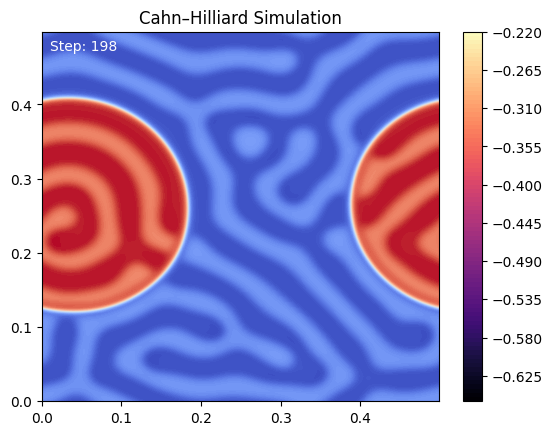

In [1686]:
fig, ax = plt.subplots()
contour = ax.contourf(X, Y, real[0], levels=100, cmap='magma')
cbar = fig.colorbar(contour, ax=ax)
ax.set_title("Cahn–Hilliard Simulation")
frame_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, color='white')

def update(i):
    global contour
    for coll in contour.collections:
        coll.remove()
    contour = ax.contourf(X, Y, real[20*i], levels=100, cmap='coolwarm')
    frame_text.set_text(f"Step: {i}")
    return contour.collections + [frame_text]

ani = FuncAnimation(fig, update, frames=int(len(real)/20) -1, interval=30)

ani.save('CahnHilliard_contour.gif', writer=PillowWriter(fps=15))
plt.show()